# Unidad 3 - EDA básico & Limpieza de datos

Además de la documentación oficial de Pandas que se menciona en este Notebook, se sugiere complementar con el Libro [Python for Data Analysis - 7 Data Cleaning](https://wesmckinney.com/book/data-cleaning)

# Importar librerias

In [53]:
import pandas as pd

# Cargar dataset

Vamos a trabajar con el Dataset `airbnb_jr.csv` que encuentran en la carpeta `datasets` en el repo oficial en Github.

Este dataset Junior, consiste en una versión simplificada del dataset original que pueden encontrar en [Inside Airbnb](https://insideairbnb.com/get-the-data/)

También puden explorar el set de datos original mediante este [Dashboard](https://insideairbnb.com/buenos-aires/) publicado en su sitio web oficial.


In [54]:
# pd.read_csv recibe la url del dataset
df = pd.read_csv('https://raw.githubusercontent.com/UADE-Python-Data-Science/583433_repo_oficial/refs/heads/main/Datasets/airbnb_jr.csv')
print("Dataset cargado exitosamente! \nDimensiones:", df.shape)

Dataset cargado exitosamente! 
Dimensiones: (1030, 10)


# EDA (Análisis Exploratorio Inicial)

Cuando cargamos un dataset, el primer paso es realizar un EDA (Exploratory Data Analysis), es decir, una exploración inicial de los datos.

El objetivo es entender rápidamente:

* qué información contiene el dataset
* cómo está estructurado
* si existen problemas como valores nulos, tipos de datos incorrectos o inconsistencias

Para esta primera inspección, utilizamos algunos métodos básicos de Pandas que nos permiten obtener una visión general del dataset de forma rápida.

### Head

El método `head()` devuelve los primeros 5 registros del DataFrame por defecto. También podemos indicar la cantidad de filas que queremos visualizar pasándola como argumento.


In [55]:
df.head()

,Host ID,Latitude,Longitude,Neighbourhood,Room Type,Bedrooms,Price,Number Reviews,Last Review,Review Scores
0,513802168,-34.602110,-58.406720,Balvanera,Entire home/apt,1.0,"$86,113.00",0,NaN,NaN
1,97542159,-34.601930,-58.377770,San Nicolas,Entire home/apt,1.0,"$69,519.86",56,2026-03-02,4.73
2,14450833,-34.582920,-58.423730,Palermo,Entire home/apt,2.0,"$278,114.00",13,2026-07-08,4.92
3,49480723,-34.585860,-58.422580,Palermo,Entire home/apt,2.0,"$190,948.00",12,2026-06-06,4.42
4,50664146,-34.609396,-58.437037,Caballito,Entire home/apt,NaN,"$64,083.00",0,NaN,NaN


De forma similar, existen otros métodos útiles:

* tail() permite ver los últimos registros
* sample() devuelve una muestra aleatoria del dataset

In [56]:
df.sample(3)

,Host ID,Latitude,Longitude,Neighbourhood,Room Type,Bedrooms,Price,Number Reviews,Last Review,Review Scores
580,187124880,-34.600014,-58.412339,Almagro,Entire home/apt,1.0,"$87,079.00",64,2026-06-14,4.95
905,70819079,-34.607050,-58.431380,Caballito,Entire home/apt,1.0,"$83,586.75",0,NaN,NaN
583,435970371,-34.591687,-58.428627,Palermo,Entire home/apt,2.0,"$208,140.25",33,2026-07-21,4.70


### Info

El método `info()` proporciona un resumen general del DataFrame, incluyendo:

* Cantidad de filas (observaciones) y columnas (variables)
* Nombres de las columnas
* Cantidad de valores no nulos por columna
* Tipo de dato de cada columna (int, float, object, etc.)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Host ID         1030 non-null   int64  
 1   Latitude        1030 non-null   float64
 2   Longitude       1030 non-null   float64
 3   Neighbourhood   1030 non-null   object 
 4   Room Type       1030 non-null   object 
 5   Bedrooms        836 non-null    float64
 6   Price           974 non-null    object 
 7   Number Reviews  1030 non-null   int64  
 8   Last Review     911 non-null    object 
 9   Review Scores   911 non-null    float64
dtypes: float64(4), int64(2), object(4)
memory usage: 80.6+ KB


En nuestro caso, `df.info()` nos indica que el dataset contiene 1030 filas (registros) y 10 columnas (variables).

Podemos observar que algunas columnas tienen valores nulos o faltantes, como ser Bedrooms o Price, por ejemplo.

Además, este método nos permite identificar el tipo de dato de cada variable, según cómo Python los ha interpretado (por ejemplo: int, float, object, etc.).

### Describe

El método `describe()` nos proporciona un resumen estadístico de las variables del dataset. Por ahora sólo contemplamos estos datos:

* count: cantidad de valores no nulos
* mean: promedio
* min: valor mínimo
* max: valor máximo

Esto permite entender la distribución de los datos,
detectar valores extremos (outliers) y
tener una primera idea de rangos y dispersión

In [58]:
df.describe() # Aplica a variables numéricas

,Host ID,Latitude,Longitude,Bedrooms,Number Reviews,Review Scores
count,1.030000e+03,1030.000000,1030.000000,836.000000,1030.000000,911.000000
mean,6.583830e+15,-34.591609,-58.417453,1.331340,41.417476,4.768957
std,1.054982e+17,0.017821,0.029856,0.746424,61.549481,0.325614
min,9.193600e+04,-34.662226,-58.520418,1.000000,0.000000,1.000000
25%,3.539551e+07,-34.603131,-58.437283,1.000000,4.000000,4.700000
50%,1.496880e+08,-34.591081,-58.420505,1.000000,17.000000,4.860000
75%,4.544077e+08,-34.581844,-58.391695,1.000000,55.000000,4.970000
max,1.714217e+18,-34.537622,-58.359810,10.000000,536.000000,5.000000


In [59]:
# Para analizar variables categóricas, podemos usar:
df.describe(include='object')

,Neighbourhood,Room Type,Price,Last Review
count,1030,1030,974,911
unique,38,4,881,286
top,Palermo,Entire home/apt,"$118,933.00",2026-07-12
freq,360,925,4,37


En este caso, el resumen incluye:

* count: cantidad de valores no nulos
* unique: cantidad de valores únicos
* top: valor más frecuente
* freq: frecuencia del valor más frecuente

### Value_counts

El método `value_counts(`) se utiliza para contar la cantidad de ocurrencias de cada valor en una columna.

Devuelve una tabla con:

* los valores únicos
* la cantidad de veces que aparece cada uno

In [ ]:
df["Neighbourhood"].value_counts()

In [65]:
df["Neighbourhood"].unique()
df["Neighbourhood"].nunique()

38

# Registos duplicados

El método `duplicated()` permite identificar filas duplicadas dentro de un DataFrame.

[Ver duplicated en la documentación oficial](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html)


### Cuantificar registros duplicados

Para obtener la cantidad de registro duplicados, aplicamos primero el método `duplicated()` y lo anidamos con el método `sum()`

In [68]:
# Veamos si hay registros duplicados y cuántos son
df.duplicated().sum()

np.int64(31)

Nos indica que hay 31 registros con los mismo valores en todas sus columnas.

### Visualizar duplicados

Como el método `duplicated()` devuelve una serie de valores True/False, podemos utilizar ese resultado como filtro para visualizar las filas duplicadas en el DataFrame.

In [ ]:
df.columns

In [73]:
# Veamos cuáles son los registros duplicados
# df[["Bedrooms", "Price"]]
# df[df.duplicated()]

# Si querés incluir también la fila original junto con sus duplicados:
df[df.duplicated(keep=False)].sort_values(by="Host ID")

# Eventualmente se pueden buscar registros duplicados de columnas específicas
# df[df.duplicated(subset=["Neighbourhood", "Room Type"], keep=False)].sort_values(by="Neighbourhood")

,Host ID,Latitude,Longitude,Neighbourhood,Room Type,Bedrooms,Price,Number Reviews,Last Review,Review Scores
549,678997,-34.575970,-58.423130,Palermo,Entire home/apt,1.0,"$71,466.99",69,2026-06-05,4.77
1020,678997,-34.575970,-58.423130,Palermo,Entire home/apt,1.0,"$71,466.99",69,2026-06-05,4.77
1001,1318605,-34.591170,-58.440920,Villa Crespo,Entire home/apt,1.0,"$37,327.07",17,2025-11-30,4.59
737,1318605,-34.591170,-58.440920,Villa Crespo,Entire home/apt,1.0,"$37,327.07",17,2025-11-30,4.59
280,2992795,-34.603622,-58.376754,San Nicolas,Entire home/apt,1.0,"$82,402.93",8,2026-05-03,4.88
...,...,...,...,...,...,...,...,...,...,...
76,548547938,-34.598110,-58.372230,Retiro,Entire home/apt,1.0,"$131,589.00",27,2026-05-01,4.89
526,725350312,-34.577146,-58.432023,Palermo,Private room,NaN,"$194,381.00",0,NaN,NaN
995,725350312,-34.577146,-58.432023,Palermo,Private room,NaN,"$194,381.00",0,NaN,NaN
521,740183862,-34.590622,-58.394420,Recoleta,Entire home/apt,2.0,"$325,324.00",16,2026-07-12,4.94


Si utilizamos `duplicated()` sin argumentos, Pandas buscará filas que estén completamente duplicadas, es decir, que tengan los mismos valores en todas sus columnas.

En cambio, si utilizamos el argumento `subset`, podemos indicar qué columnas específicas queremos analizar para identificar duplicados, sin necesidad de que toda la fila sea idéntica.

### Eliminar registros duplicados

Una vez que identificamos los registros duplicados en nuestro dataset, el siguiente paso es eliminarlos. En Pandas, utilizamos el método `drop_duplicates()`, que nos permite quedarnos con una única ocurrencia de cada registro.

[Ver drop_duplicates Doc](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html)


Argumentos asociados:
* inplace
* ignore_index
* keep
* subset

inplace: si es True, modifica el DataFrame original, evitando tener que reasignar el resultado.

ignore_index: si es True, reinicia el índice del DataFrame resultante.

keep: define qué registro conservar

* 'first' (default): mantiene el primero
* 'last': mantiene el último
* False: elimina todos los duplicados

subset: indica las columnas a considerar para identificar duplicados. Ej: subset=['Host ID']

In [74]:
# Eliminamos los duplicados y reasignamos el resultado
df_pp = df.drop_duplicates()

In [ ]:
# Validamos repitiendo el primer comando
df_pp.duplicated().sum()

## Playground:
* Copiar el dataframe original antes de explorar los parámetros de drop_duplicates()
* Usar como referencia el registro con Host ID = 678997
* Explorar los parámetros inplace, keep, ignore_index, subset 



In [75]:
# Copiar del dataframe original
# df1 = df # copia la posicion de memoria
df1 = df.copy() # genera una variable nueva

In [76]:
# Verificamos que existen registros duplicados
df1.duplicated().sum()

np.int64(31)

In [77]:
# Filtramos por Host ID = 678997 antes de eliminar
df1[df1["Host ID"] == 678997]

,Host ID,Latitude,Longitude,Neighbourhood,Room Type,Bedrooms,Price,Number Reviews,Last Review,Review Scores
549,678997,-34.57597,-58.42313,Palermo,Entire home/apt,1.0,"$71,466.99",69,2026-06-05,4.77
1020,678997,-34.57597,-58.42313,Palermo,Entire home/apt,1.0,"$71,466.99",69,2026-06-05,4.77


In [80]:
# Decomentar las lineas de a una y ejecutar, repetir el ciclo para explorar los otros parámetros
# df1.drop_duplicates() # No sobrescribe el dataframe
# df1 = df1.drop_duplicates() # Sobrescrimo manualmente el dataframe
# df1 = df1.drop_duplicates(keep="first") # keep="first", "last", False
df1.drop_duplicates(inplace=True) #Sobreescribe el dataframe
# df_pp = df1.drop_duplicates() # Elimina sin afectar el df original y se guarda en df_pp1

In [81]:
# Validamos que no hay duplicados
df1.duplicated().sum()

np.int64(0)

In [ ]:
# Filtramos por Host ID = 678997 luego de eliminar
df1[df1["Host ID"] == 678997]

In [ ]:
# Info debería indicar que se redujo la cantidad de registros
df1.info()

# Valores nulos

Los valores nulos, que representan la ausencia de información, pueden presentarse por diversas razones, como errores durante la recolección de datos, problemas de formulario o simplemente porque algunos encuestados eligen no responder.

La presencia de valores nulos puede complicar análisis estadísticos y modelos predictivos, ya que muchos algoritmos no pueden funcionar correctamente con datos faltantes.


Existen varias estrategias para tratar los valores nulos:
* Eliminación: En algunos casos, puede ser apropiado eliminar filas o columnas enteras que contienen valores nulos si estos son pocos y no afectan significativamente al análisis.

* Imputación: Consiste en rellenar los valores nulos con un valor adecuado. Metodologías comunes incluyen la imputación con la media, mediana o moda de la columna.

* Predicción: En algunos casos, se pueden construir modelos predictivos que estimen los valores nulos en función de otros datos disponibles.


### Cuantificar valores nulos

Durante el EDA, vimos que el método info() nos informaba la cantidad de datos no-nulos por columna/variable. Veamos además cómo contabilizar la cantidad de nulos.

El método `isnull()` se utiliza para eliminar filas o columnas que contienen valores nulos.

[Ver isnull doc](https://pandas.pydata.org/docs/reference/api/pandas.isnull.html)

In [82]:
# Valores no-nulos por columna/variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Host ID         1030 non-null   int64  
 1   Latitude        1030 non-null   float64
 2   Longitude       1030 non-null   float64
 3   Neighbourhood   1030 non-null   object 
 4   Room Type       1030 non-null   object 
 5   Bedrooms        836 non-null    float64
 6   Price           974 non-null    object 
 7   Number Reviews  1030 non-null   int64  
 8   Last Review     911 non-null    object 
 9   Review Scores   911 non-null    float64
dtypes: float64(4), int64(2), object(4)
memory usage: 80.6+ KB


In [86]:
# Valores nulos por columna/variable
# df.isnull().sum()
# O eventualmente, mostrar sólo los campos con nulos > 0
df.isnull().sum()[df.isnull().sum() > 0]

Bedrooms         194
Price             56
Last Review      119
Review Scores    119
dtype: int64

In [87]:
# Valores nulos de una columna/variable específica
# df['Bedrooms'].isnull().value_counts()
df['Bedrooms'].isnull().sum() # cuenta los True

np.int64(194)

In [88]:
# Calular el porcentaje de valores nulos por columna
nulos_calificacion = (df['Bedrooms'].isnull().sum()) / (len(df)) * 100
print(f"{nulos_calificacion:.2f} %")

18.83 %


### Visualizar nulos

Para identificar filas que contienen al menos un valor nulo, podemos utilizar:

`df[df.isnull().any(axis=1)]`

* df.isnull() → genera un DataFrame de valores True/False, donde True indica un valor nulo
* .any(axis=1) → evalúa cada fila y devuelve True si al menos una columna tiene un valor nulo
* df[...] → usamos ese resultado como filtro para mostrar solo esas filas


In [89]:
# Visualizar registros con al menos un dato nulo o faltante
df[df.isnull().any(axis=1)]

,Host ID,Latitude,Longitude,Neighbourhood,Room Type,Bedrooms,Price,Number Reviews,Last Review,Review Scores
0,513802168,-34.602110,-58.406720,Balvanera,Entire home/apt,1.0,"$86,113.00",0,NaN,NaN
4,50664146,-34.609396,-58.437037,Caballito,Entire home/apt,NaN,"$64,083.00",0,NaN,NaN
5,307608498,-34.590083,-58.449108,Chacarita,Entire home/apt,1.0,"$129,131.92",0,NaN,NaN
7,4143666,-34.598520,-58.430500,Villa Crespo,Entire home/apt,NaN,"$84,956.67",81,2026-06-01,4.77
12,440348398,-34.596770,-58.426710,Villa Crespo,Entire home/apt,1.0,"$51,766.00",0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1021,14450833,-34.583237,-58.404347,Palermo,Entire home/apt,3.0,"$79,605.86",0,NaN,NaN
1022,408029626,-34.568941,-58.448849,Colegiales,Entire home/apt,NaN,NaN,39,2026-03-29,4.77
1024,16133446,-34.582880,-58.422210,Palermo,Entire home/apt,NaN,"$55,162.00",10,2026-07-04,5.00
1025,55553719,-34.577741,-58.438862,Palermo,Entire home/apt,NaN,"$119,442.60",0,NaN,NaN


## Playground

Explora los siguientes bloques de código para ver sus variantes

Podes mejorar la visualización usando `.sort_values(by="Bedrooms", ascending=False)`

In [ ]:
# 2. Filas que NO tienen ningún nulo
df[df.notnull().all(axis=1)]

In [ ]:
# 3. Filas donde una columna específica es nula
df[df["Bedrooms"].isnull()]

In [ ]:
# 4. Nulo en cualquiera de dos columnas
df[
    df[["Price", "Review Scores"]]
    .isnull()
    .any(axis=1)
]

In [ ]:
# 6. Nulo simultáneamente en dos columnas
df[
    df[["Price", "Review Scores"]]
    .isnull()
    .all(axis=1)
]

# Eliminar nulos

El método `dropna()` se utiliza para eliminar filas o columnas que contienen valores nulos.

[Ver dropna doc](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)


In [90]:
# Eliminamos los registros con algún valor nulo
df1 = df.dropna()

In [91]:
# Validamos
df1.isnull().sum()

Host ID           0
Latitude          0
Longitude         0
Neighbourhood     0
Room Type         0
Bedrooms          0
Price             0
Number Reviews    0
Last Review       0
Review Scores     0
dtype: int64

Argumentos asociados:

* inplace
* ignore_index
* subset
* how
* thresh
* axis

## Playground

Ejecuta estos tres primeros bloques luego de explorar las diferentes opciones

In [ ]:
# Copiar del dataframe original
df1 = df.copy()

In [ ]:
# Cuantificar nulos por columna
df1.isnull().sum()[df1.isnull().sum() > 0]

In [ ]:
df1.head()
# Listar los primeros 5 registros, presta atención al index

In [ ]:
# Visualizar registros con al menos un dato nulo o faltante
df1[df1.isnull().any(axis=1)]

Ejecuta  cada opción de a uno, luego revisa el impacto cuantificando y mostrando nulos

In [ ]:
# Variante con inplace, evita reasignar
df1.dropna(inplace=True)

In [ ]:
# Variante con ignore_index, resetea los índices luego de eliminar
df1 = df.copy()
df1.dropna(inplace=True, ignore_index=True)

In [ ]:
# Variante con subset, indica en qué columnas buscar nulos
df1 = df.copy()
df1.dropna(inplace=True, subset=['Bedrooms'])

In [ ]:
# Variante con how ('all', 'any')
# indica si todos los valores o algunos deben ser nulos para elimnar
df1 = df.copy()
df1.dropna(inplace=True, how='all')

In [ ]:
# Variante con axis (0: fila, 1: columna)
# indica si busca nulos a nivel de filas o columnas
df1 = df.copy()
df1.dropna(inplace=True, axis=1)

# Imputar nulos

El método fillna() se utiliza para completar valores nulos.

[Ver fillna doc](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)

El valor que usamos para completar los faltantes, podría ser la media o la mediana, pero no se aconseja hacerlo ya que podría sergar los datos.

In [92]:
# Hacemos una copia previa del dataframe original
df1 = df.copy()

In [93]:
# Cuantificar nulos por columna
df1.isnull().sum()[df1.isnull().sum() > 0]

Bedrooms         194
Price             56
Last Review      119
Review Scores    119
dtype: int64

In [94]:
# Completamos solo los valores nulos de la columna Bedrooms
df1["Bedrooms"] = df1["Bedrooms"].fillna(df1["Bedrooms"].mean()) # cambiar por median y evaluar resultado en el plot

In [95]:
# Cuantificar nulos por columna
df1.isnull().sum()[df1.isnull().sum() > 0]

Price             56
Last Review      119
Review Scores    119
dtype: int64

Solo a modo ilustrativo, luego veremos como generar visualizaciones, veamos el impacto en la distribución de la variable Bedrooms, de completar los nulos con la media (mean) o la mediana (median)

Text(0, 0.5, 'Frecuencia')

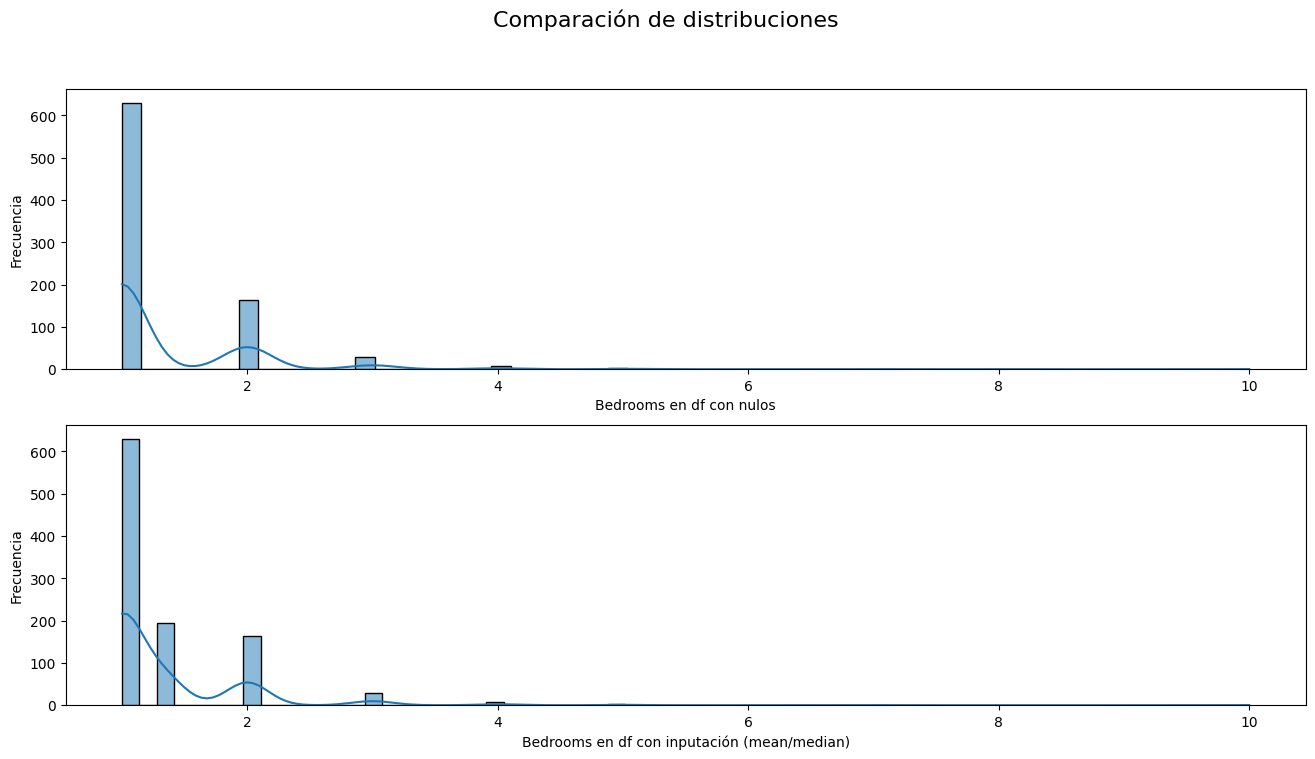

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir el tamaño del lienzo
plt.figure(figsize=(16, 8))
# Título principal
plt.suptitle("Comparación de distribuciones", fontsize=16)

plt.subplot(2,1,1)
sns.histplot(data=df, x="Bedrooms", bins="auto", kde=True)
plt.xlabel("Bedrooms en df con nulos")
plt.ylabel("Frecuencia")

plt.subplot(2,1,2)
sns.histplot(data=df1, x="Bedrooms", bins="auto", kde=True)
plt.xlabel("Bedrooms en df con inputación (mean/median)")
plt.ylabel("Frecuencia")

## Exportar dataset

In [ ]:
# Guardamos el dataset resultante en el drive
ruta = 'airbnb_jr_clean.csv'
df.to_csv(ruta, index=False)